# 🌾 India Crop Yield Prediction — Notebook 2: Preprocessing & Feature Engineering

**Goal:** Clean the dataset, handle missing values, encode categorical features, engineer new features, and prepare data for modelling.

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 2. Load Raw Dataset

In [2]:
DATA_PATH = 'crop_production.csv'  # Update path if needed

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape}')
df.head()

Loaded: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


## 3. Handle Missing Values

In [3]:
print('Missing values before cleaning:')
print(df.isnull().sum())

# Drop rows where target (Yield or Production) is missing
target_col = 'Yield'
if target_col in df.columns:
    before = len(df)
    df = df.dropna(subset=[target_col])
    print(f'\nDropped {before - len(df)} rows with missing Yield.')

# Impute numerical columns with median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'Imputed {col} with median = {median_val:.4f}')

# Impute categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'Imputed {col} with mode = {mode_val}')

print('\nMissing values after cleaning:')
print(df.isnull().sum())

Missing values before cleaning:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

Dropped 0 rows with missing Yield.

Missing values after cleaning:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


## 4. Remove Outliers (IQR Method on Yield)

In [4]:
def remove_outliers_iqr(data, column, factor=3.0):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    before = len(data)
    data = data[(data[column] >= lower) & (data[column] <= upper)]
    print(f'[{column}] Removed {before - len(data)} outliers (bounds: {lower:.2f} – {upper:.2f})')
    return data

df = remove_outliers_iqr(df, 'Yield', factor=3.0)
print(f'\nDataset after outlier removal: {df.shape}')

[Yield] Removed 2332 outliers (bounds: -4.77 – 7.76)

Dataset after outlier removal: (17357, 10)


## 5. Strip & Standardize String Values

In [5]:
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Standardize Season values
if 'Season' in df.columns:
    season_map = {
        'Kharif': 'Kharif',
        'Rabi': 'Rabi',
        'Whole Year': 'Whole Year',
        'Autumn': 'Autumn',
        'Winter': 'Winter',
        'Summer': 'Summer'
    }
    df['Season'] = df['Season'].str.strip()

print('Unique seasons:', df['Season'].unique() if 'Season' in df.columns else 'N/A')

Unique seasons: ['Whole Year' 'Kharif' 'Rabi' 'Autumn' 'Summer' 'Winter']


## 6. Feature Engineering

In [6]:
# 6.1 Fertilizer & Pesticide intensity per hectare
if 'Fertilizer' in df.columns and 'Area' in df.columns:
    df['Fertilizer_Per_Ha'] = df['Fertilizer'] / (df['Area'] + 1e-6)
    print('Created: Fertilizer_Per_Ha')

if 'Pesticide' in df.columns and 'Area' in df.columns:
    df['Pesticide_Per_Ha'] = df['Pesticide'] / (df['Area'] + 1e-6)
    print('Created: Pesticide_Per_Ha')

# 6.2 Rainfall categories
if 'Annual_Rainfall' in df.columns:
    df['Rainfall_Category'] = pd.cut(
        df['Annual_Rainfall'],
        bins=[0, 500, 1000, 1500, 2000, 99999],
        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
    ).astype(str)
    print('Created: Rainfall_Category')

# 6.3 Decade feature
if 'Crop_Year' in df.columns:
    df['Decade'] = (df['Crop_Year'] // 10) * 10
    print('Created: Decade')

# 6.4 Production per rainfall unit
if 'Production' in df.columns and 'Annual_Rainfall' in df.columns:
    df['Production_Per_Rainfall'] = df['Production'] / (df['Annual_Rainfall'] + 1e-6)
    print('Created: Production_Per_Rainfall')

# 6.5 Log transforms for skewed features
skewed_cols = ['Area', 'Production', 'Fertilizer', 'Pesticide', 'Fertilizer_Per_Ha', 'Pesticide_Per_Ha']
for col in skewed_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])
        print(f'Created: log_{col}')

print(f'\nNew dataset shape: {df.shape}')

Created: Fertilizer_Per_Ha
Created: Pesticide_Per_Ha
Created: Rainfall_Category
Created: Decade
Created: Production_Per_Rainfall
Created: log_Area
Created: log_Production
Created: log_Fertilizer
Created: log_Pesticide
Created: log_Fertilizer_Per_Ha
Created: log_Pesticide_Per_Ha

New dataset shape: (17357, 21)


## 7. Encode Categorical Variables

In [7]:
label_encoders = {}

encode_cols = ['Crop', 'Season', 'State', 'Rainfall_Category']
encode_cols = [c for c in encode_cols if c in df.columns]

for col in encode_cols:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'Encoded: {col} → {col}_enc ({len(le.classes_)} classes)')

# Save encoders
joblib.dump(label_encoders, 'label_encoders.pkl')
print('\nLabel encoders saved to label_encoders.pkl')

Encoded: Crop → Crop_enc (55 classes)
Encoded: Season → Season_enc (6 classes)
Encoded: State → State_enc (30 classes)
Encoded: Rainfall_Category → Rainfall_Category_enc (5 classes)

Label encoders saved to label_encoders.pkl


## 8. Feature Selection for Modelling

In [8]:
# Select features for modelling
feature_cols = [
    'Crop_Year', 'Decade',
    'log_Area', 'log_Production',
    'Annual_Rainfall',
    'log_Fertilizer', 'log_Pesticide',
    'Fertilizer_Per_Ha', 'Pesticide_Per_Ha',
    'log_Fertilizer_Per_Ha', 'log_Pesticide_Per_Ha',
    'Production_Per_Rainfall',
    'Crop_enc', 'Season_enc', 'State_enc', 'Rainfall_Category_enc'
]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]
target = 'Yield'

print('Selected features:')
for f in feature_cols:
    print(f'  - {f}')
print(f'\nTarget: {target}')

Selected features:
  - Crop_Year
  - Decade
  - log_Area
  - log_Production
  - Annual_Rainfall
  - log_Fertilizer
  - log_Pesticide
  - Fertilizer_Per_Ha
  - Pesticide_Per_Ha
  - log_Fertilizer_Per_Ha
  - log_Pesticide_Per_Ha
  - Production_Per_Rainfall
  - Crop_enc
  - Season_enc
  - State_enc
  - Rainfall_Category_enc

Target: Yield


## 9. Train / Validation / Test Split

In [9]:
X = df[feature_cols]
y = df[target]

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train set : {X_train.shape}')
print(f'Val set   : {X_val.shape}')
print(f'Test set  : {X_test.shape}')

Train set : (12149, 16)
Val set   : (2604, 16)
Test set  : (2604, 16)


## 10. Feature Scaling

In [10]:
scaler = RobustScaler()  # Robust to remaining outliers

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)

joblib.dump(scaler, 'robust_scaler.pkl')
print('RobustScaler saved to robust_scaler.pkl')

RobustScaler saved to robust_scaler.pkl


## 11. Save Processed Data

In [11]:
import os
os.makedirs('processed', exist_ok=True)

X_train_scaled.to_csv('processed/X_train.csv', index=False)
X_val_scaled.to_csv('processed/X_val.csv', index=False)
X_test_scaled.to_csv('processed/X_test.csv', index=False)

y_train.to_csv('processed/y_train.csv', index=False)
y_val.to_csv('processed/y_val.csv', index=False)
y_test.to_csv('processed/y_test.csv', index=False)

# Also save unscaled for tree-based models
X_train.to_csv('processed/X_train_raw.csv', index=False)
X_val.to_csv('processed/X_val_raw.csv', index=False)
X_test.to_csv('processed/X_test_raw.csv', index=False)

# Save full processed df
df.to_csv('processed/crop_processed.csv', index=False)

print('All processed datasets saved in ./processed/')
print('\nFeature list saved:')
import json
with open('processed/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)
print(json.dumps(feature_cols, indent=2))

All processed datasets saved in ./processed/

Feature list saved:
[
  "Crop_Year",
  "Decade",
  "log_Area",
  "log_Production",
  "Annual_Rainfall",
  "log_Fertilizer",
  "log_Pesticide",
  "Fertilizer_Per_Ha",
  "Pesticide_Per_Ha",
  "log_Fertilizer_Per_Ha",
  "log_Pesticide_Per_Ha",
  "Production_Per_Rainfall",
  "Crop_enc",
  "Season_enc",
  "State_enc",
  "Rainfall_Category_enc"
]


## 12. Feature Correlation with Target

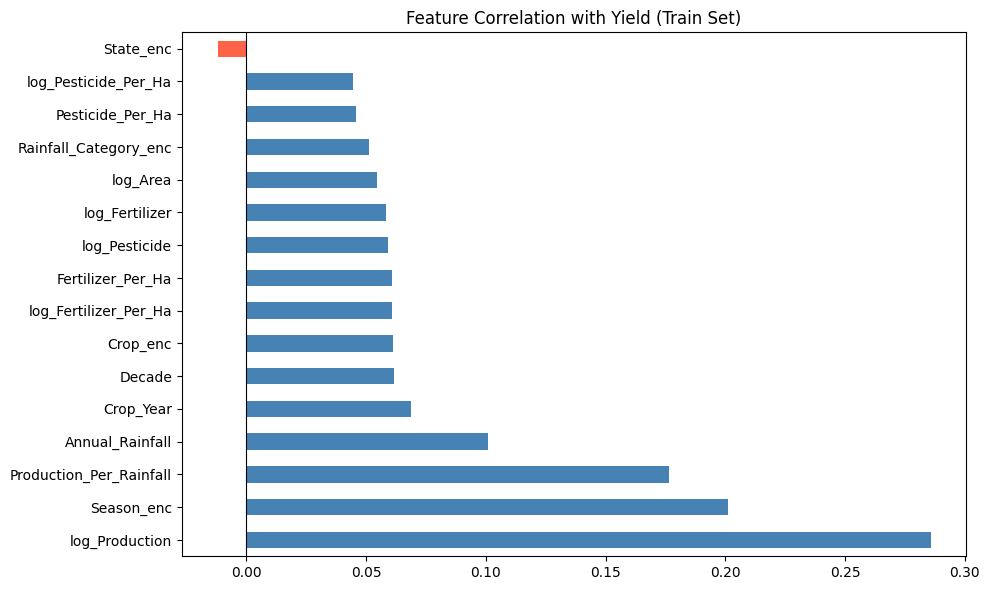


Top correlations with Yield:
log_Production             0.285757
Season_enc                 0.201136
Production_Per_Rainfall    0.176326
Annual_Rainfall            0.101009
Crop_Year                  0.068771
Decade                     0.061798
Crop_enc                   0.061340
log_Fertilizer_Per_Ha      0.060712
Fertilizer_Per_Ha          0.060627
log_Pesticide              0.059238
dtype: float64


In [12]:
corr_with_target = X_train_scaled.corrwith(y_train).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
corr_with_target.plot(kind='barh', ax=ax,
                      color=['tomato' if v < 0 else 'steelblue' for v in corr_with_target])
ax.set_title('Feature Correlation with Yield (Train Set)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_target_correlation.png')
plt.show()

print('\nTop correlations with Yield:')
print(corr_with_target.head(10))

---
 **Preprocessing complete.** Proceed to `03_baseline_models.ipynb`.